In [33]:
import numpy as np
import matplotlib.pyplot as plt
import os
import tensorflow as tf

import keras
from keras.datasets import cifar10
from keras.optimizers import Adam
from keras.models import Sequential, Model
from keras.layers import (
    Dense, Reshape, Flatten, LeakyReLU, BatchNormalization,
    Conv2D, Conv2DTranspose, Input, Dropout
)

In [34]:
CIFAR_CLASS   = 1        # 0=plane 1=car 2=bird 3=cat 4=deer
                          # 5=dog  6=frog 7=horse 8=ship 9=truck
LATENT_DIM    = 100
IMG_SHAPE     = (32, 32, 3)
EPOCHS        = 5000
BATCH_SIZE    = 64
SAVE_INTERVAL = 500

os.makedirs("images", exist_ok=True)
print(f"Training on CIFAR-10 class {CIFAR_CLASS} | latent_dim={LATENT_DIM}")

Training on CIFAR-10 class 1 | latent_dim=100


In [35]:
def build_generator(latent_dim, channels):
    model = Sequential(name="Generator")

    # Project & reshape: latent_dim → 4×4×256
    model.add(Dense(4 * 4 * 256, input_dim=latent_dim))
    model.add(Reshape((4, 4, 256)))
    model.add(BatchNormalization(momentum=0.8))
    model.add(LeakyReLU(negative_slope=0.2))

    # 4×4 → 8×8
    model.add(Conv2DTranspose(128, kernel_size=4, strides=2, padding='same'))
    model.add(BatchNormalization(momentum=0.8))
    model.add(LeakyReLU(negative_slope=0.2))

    # 8×8 → 16×16
    model.add(Conv2DTranspose(64, kernel_size=4, strides=2, padding='same'))
    model.add(BatchNormalization(momentum=0.8))
    model.add(LeakyReLU(negative_slope=0.2))

    # 16×16 → 32×32  (tanh output)
    model.add(Conv2DTranspose(channels, kernel_size=4,
                              strides=2, padding='same', activation='tanh'))

    model.summary()

    noise = Input(shape=(latent_dim,))
    img   = model(noise)
    return Model(noise, img)

generator = build_generator(LATENT_DIM, IMG_SHAPE[2])


Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 4096)           │       413,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_18 (LeakyReLU)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_9              │ (None, 8, 8, 128)      │       524,416 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_19 (LeakyReLU)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_10             │ (None, 16, 16, 64)     │       131,136 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_20 (LeakyReLU)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_11             │ (None, 32, 32, 3)      │         3,075 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,074,115 (4.10 MB)

 Trainable params: 1,073,219 (4.09 MB)

 Non-trainable params: 896 (3.50 KB)

In [36]:
def build_discriminator(img_shape):
    model = Sequential(name="Discriminator")

    # 32×32 → 16×16
    model.add(Conv2D(64, kernel_size=4, strides=2, padding='same',
                     input_shape=img_shape))
    model.add(LeakyReLU(negative_slope=0.2))
    model.add(Dropout(0.25))

    # 16×16 → 8×8
    model.add(Conv2D(128, kernel_size=4, strides=2, padding='same'))
    model.add(BatchNormalization(momentum=0.8))
    model.add(LeakyReLU(negative_slope=0.2))
    model.add(Dropout(0.25))

    # 8×8 → 4×4
    model.add(Conv2D(256, kernel_size=4, strides=2, padding='same'))
    model.add(BatchNormalization(momentum=0.8))
    model.add(LeakyReLU(negative_slope=0.2))
    model.add(Dropout(0.25))

    model.add(Flatten())
    model.add(Dense(1, activation='sigmoid'))
    model.summary()

    img      = Input(shape=img_shape)
    validity = model(img)
    return Model(img, validity)

discriminator = build_discriminator(IMG_SHAPE)


Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_21 (LeakyReLU)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_22 (LeakyReLU)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 4, 4, 256)      │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_23 (LeakyReLU)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 664,513 (2.53 MB)

 Trainable params: 663,745 (2.53 MB)

 Non-trainable params: 768 (3.00 KB)

In [37]:
opt_d = Adam(learning_rate=0.0002, beta_1=0.5)
opt_g = Adam(learning_rate=0.0002, beta_1=0.5)

# Compile discriminator
discriminator.compile(
    loss='binary_crossentropy', optimizer=opt_d, metrics=['accuracy'])

# Compile generator separately (no combined model needed)
generator.compile(optimizer=opt_g, loss='binary_crossentropy')

print("Models compiled ✓")


Models compiled ✓


Class 'car' — 5000 images, shape (32, 32, 3)


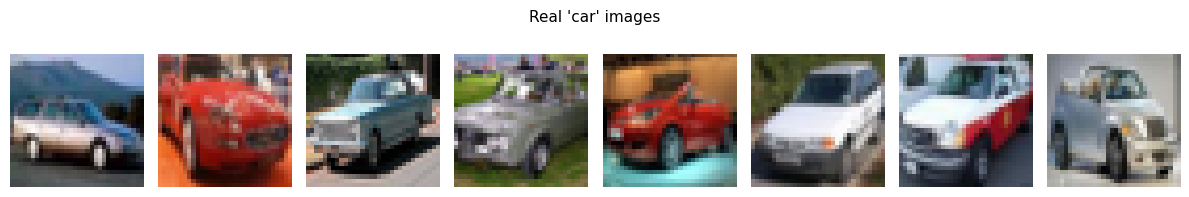

In [38]:
(X_all, y_all), _ = cifar10.load_data()

X_train = X_all[y_all.flatten() == CIFAR_CLASS]
X_train = (X_train.astype(np.float32) - 127.5) / 127.5   # → [-1, 1]

class_names = ['airplane','car','bird','cat','deer',
               'dog','frog','horse','ship','truck']
print(f"Class '{class_names[CIFAR_CLASS]}' — {X_train.shape[0]} images, "
      f"shape {X_train.shape[1:]}")

# Preview a few real images
fig, axs = plt.subplots(1, 8, figsize=(12, 2))
for i, ax in enumerate(axs):
    ax.imshow(np.clip(0.5 * X_train[i] + 0.5, 0, 1))
    ax.axis('off')
fig.suptitle(f"Real '{class_names[CIFAR_CLASS]}' images", fontsize=11)
plt.tight_layout()
plt.show()


In [39]:
def save_imgs(epoch, generator, latent_dim, r=5, c=5):
    noise    = np.random.normal(0, 1, (r * c, latent_dim))
    gen_imgs = generator.predict(noise, verbose=0)
    gen_imgs = np.clip(0.5 * gen_imgs + 0.5, 0, 1)

    fig, axs = plt.subplots(r, c, figsize=(8, 8))
    cnt = 0
    for i in range(r):
        for j in range(c):
            axs[i, j].imshow(gen_imgs[cnt])
            axs[i, j].axis('off')
            cnt += 1
    fig.suptitle(f"Epoch {epoch}", fontsize=13)
    fig.savefig(f"images/cifar10_class{CIFAR_CLASS}_epoch{epoch}.png", dpi=100)
    plt.show()
    plt.close()

[Epoch     0]  D loss: 0.8554  acc: 52.3%  |  G loss: 0.6815


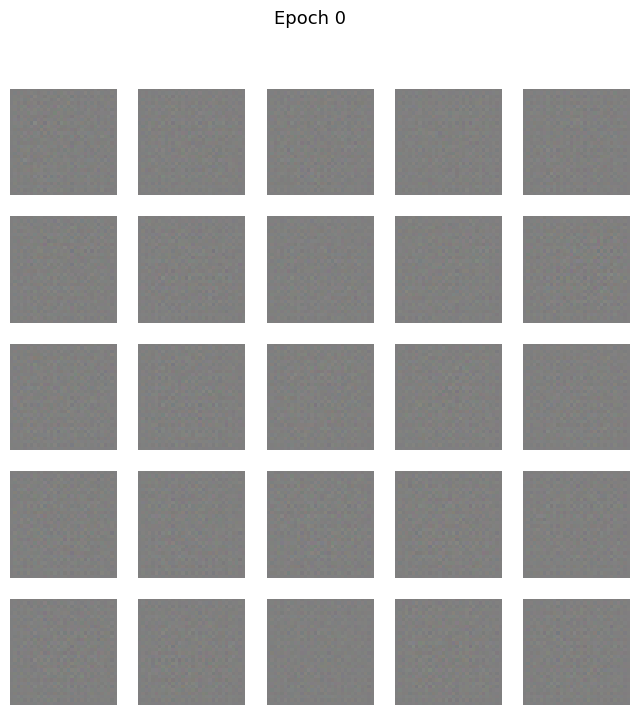

[Epoch   100]  D loss: 0.0887  acc: 97.3%  |  G loss: 0.0624
[Epoch   200]  D loss: 0.0458  acc: 98.6%  |  G loss: 0.0215
[Epoch   300]  D loss: 0.0309  acc: 99.1%  |  G loss: 0.0154
[Epoch   400]  D loss: 0.0233  acc: 99.3%  |  G loss: 0.0092
[Epoch   500]  D loss: 0.0187  acc: 99.5%  |  G loss: 0.0045


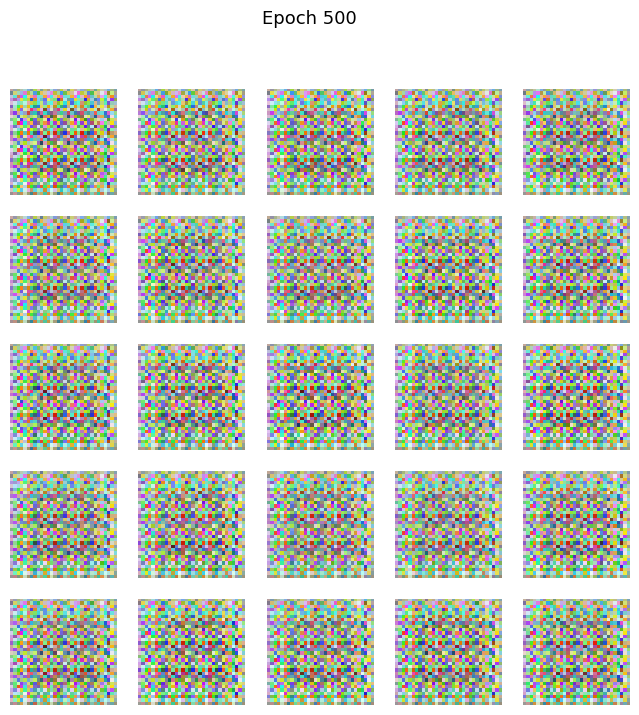

[Epoch   600]  D loss: 0.0156  acc: 99.5%  |  G loss: 0.0062
[Epoch   700]  D loss: 0.0134  acc: 99.6%  |  G loss: 0.0035
[Epoch   800]  D loss: 0.0117  acc: 99.7%  |  G loss: 0.0030
[Epoch   900]  D loss: 0.0104  acc: 99.7%  |  G loss: 0.0024
[Epoch  1000]  D loss: 0.0094  acc: 99.7%  |  G loss: 0.0017


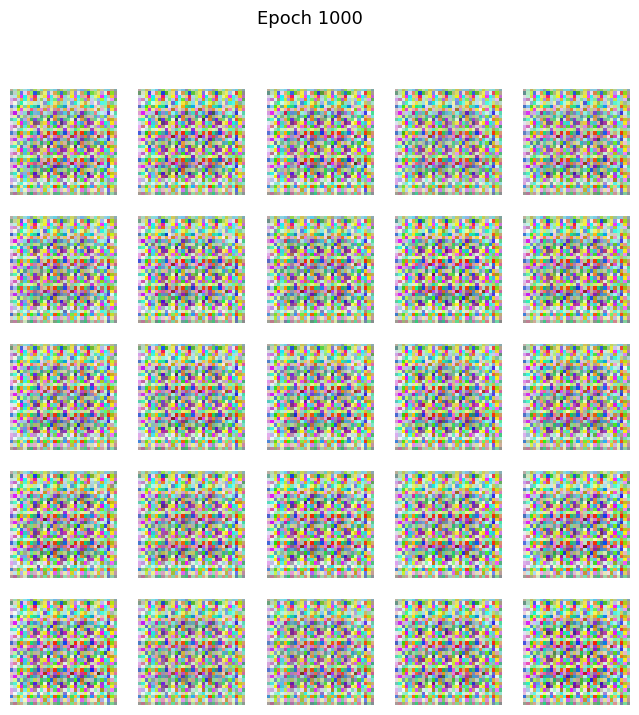

[Epoch  1100]  D loss: 0.0085  acc: 99.8%  |  G loss: 0.0014
[Epoch  1200]  D loss: 0.0078  acc: 99.8%  |  G loss: 0.0011
[Epoch  1300]  D loss: 0.0072  acc: 99.8%  |  G loss: 0.0014
[Epoch  1400]  D loss: 0.0067  acc: 99.8%  |  G loss: 0.0008
[Epoch  1500]  D loss: 0.0063  acc: 99.8%  |  G loss: 0.0009


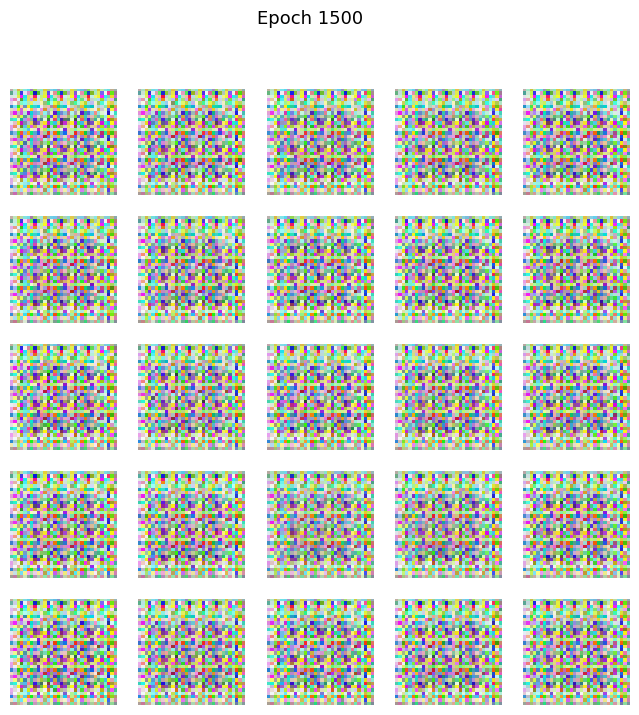

[Epoch  1600]  D loss: 0.0059  acc: 99.8%  |  G loss: 0.0007
[Epoch  1700]  D loss: 0.0055  acc: 99.8%  |  G loss: 0.0008
[Epoch  1800]  D loss: 0.0052  acc: 99.8%  |  G loss: 0.0006
[Epoch  1900]  D loss: 0.0050  acc: 99.9%  |  G loss: 0.0009
[Epoch  2000]  D loss: 0.0047  acc: 99.9%  |  G loss: 0.0005


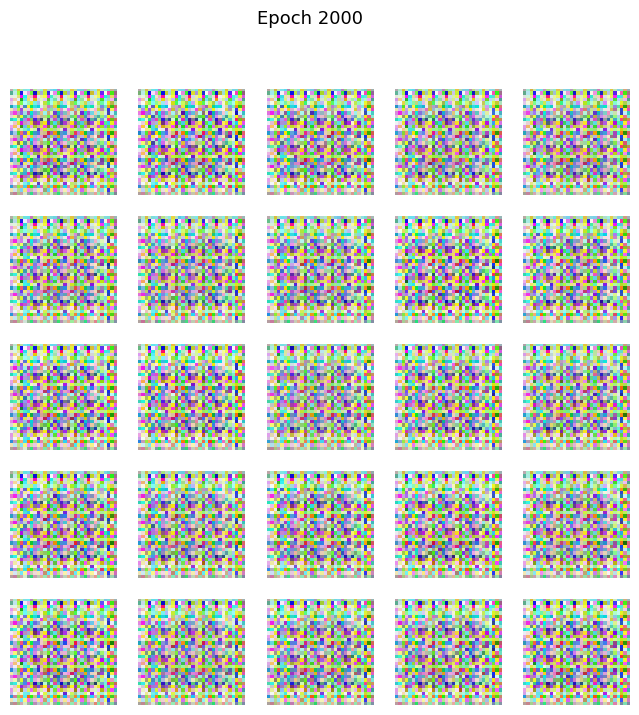

[Epoch  2100]  D loss: 0.0045  acc: 99.9%  |  G loss: 0.0004
[Epoch  2200]  D loss: 0.0043  acc: 99.9%  |  G loss: 0.0002
[Epoch  2300]  D loss: 0.0041  acc: 99.9%  |  G loss: 0.0004
[Epoch  2400]  D loss: 0.0039  acc: 99.9%  |  G loss: 0.0003
[Epoch  2500]  D loss: 0.0038  acc: 99.9%  |  G loss: 0.0005


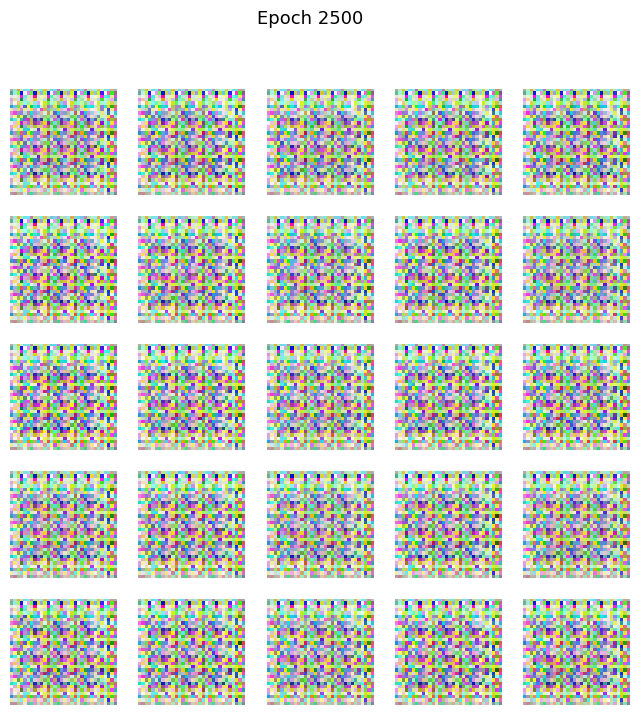

[Epoch  2600]  D loss: 0.0036  acc: 99.9%  |  G loss: 0.0003
[Epoch  2700]  D loss: 0.0035  acc: 99.9%  |  G loss: 0.0002
[Epoch  2800]  D loss: 0.0034  acc: 99.9%  |  G loss: 0.0003
[Epoch  2900]  D loss: 0.0033  acc: 99.9%  |  G loss: 0.0003
[Epoch  3000]  D loss: 0.0031  acc: 99.9%  |  G loss: 0.0004


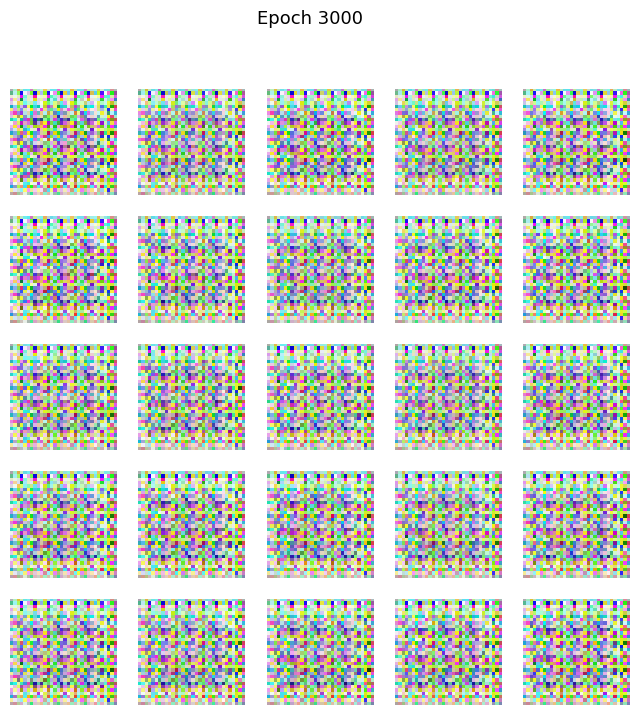

[Epoch  3100]  D loss: 0.0030  acc: 99.9%  |  G loss: 0.0001
[Epoch  3200]  D loss: 0.0029  acc: 99.9%  |  G loss: 0.0001
[Epoch  3300]  D loss: 0.0029  acc: 99.9%  |  G loss: 0.0002
[Epoch  3400]  D loss: 0.0028  acc: 99.9%  |  G loss: 0.0001
[Epoch  3500]  D loss: 0.0027  acc: 99.9%  |  G loss: 0.0001


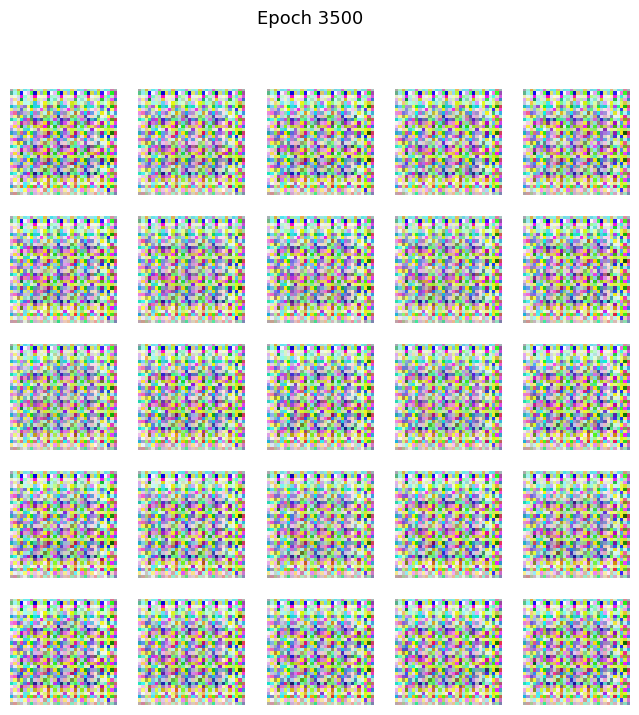

[Epoch  3600]  D loss: 0.0026  acc: 99.9%  |  G loss: 0.0001
[Epoch  3700]  D loss: 0.0025  acc: 99.9%  |  G loss: 0.0001
[Epoch  3800]  D loss: 0.0025  acc: 99.9%  |  G loss: 0.0001
[Epoch  3900]  D loss: 0.0024  acc: 99.9%  |  G loss: 0.0001
[Epoch  4000]  D loss: 0.0024  acc: 99.9%  |  G loss: 0.0001


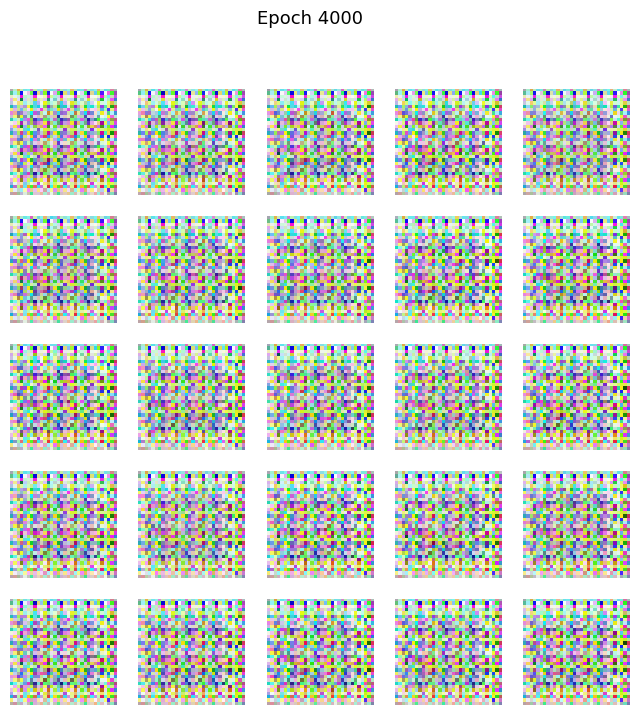

[Epoch  4100]  D loss: 0.0023  acc: 99.9%  |  G loss: 0.0001
[Epoch  4200]  D loss: 0.0022  acc: 99.9%  |  G loss: 0.0001
[Epoch  4300]  D loss: 0.0022  acc: 99.9%  |  G loss: 0.0001
[Epoch  4400]  D loss: 0.0021  acc: 99.9%  |  G loss: 0.0001
[Epoch  4500]  D loss: 0.0021  acc: 99.9%  |  G loss: 0.0000


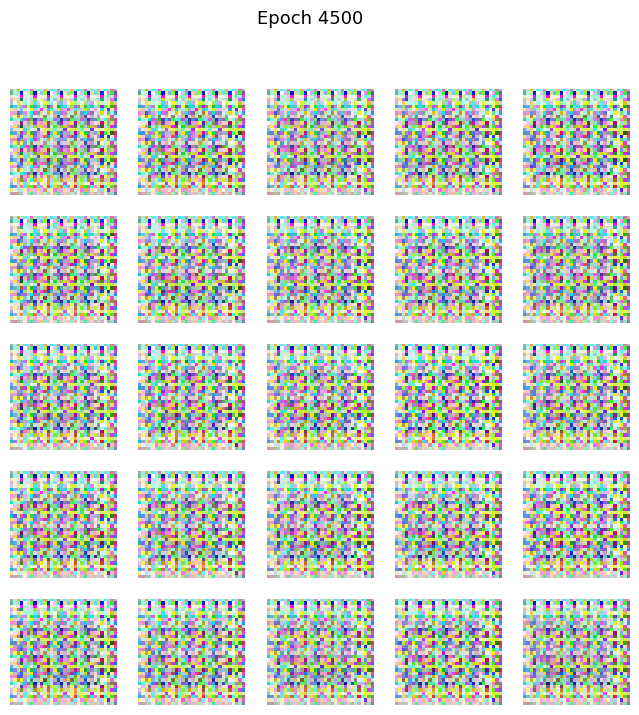

[Epoch  4600]  D loss: 0.0020  acc: 99.9%  |  G loss: 0.0000
[Epoch  4700]  D loss: 0.0020  acc: 99.9%  |  G loss: 0.0000
[Epoch  4800]  D loss: 0.0020  acc: 99.9%  |  G loss: 0.0001
[Epoch  4900]  D loss: 0.0019  acc: 99.9%  |  G loss: 0.0001


In [40]:
half         = BATCH_SIZE // 2
real_labels  = np.ones((half, 1))
fake_labels  = np.zeros((half, 1))
d_losses, g_losses = [], []

for epoch in range(EPOCHS):

    # ── Discriminator step ──────────────────────────────────────
    idx   = np.random.randint(0, X_train.shape[0], half)
    real  = X_train[idx]
    noise = np.random.normal(0, 1, (half, LATENT_DIM))
    fake  = generator.predict(noise, verbose=0)

    d_loss_r = discriminator.train_on_batch(real, real_labels)
    d_loss_f = discriminator.train_on_batch(fake, fake_labels)
    d_loss   = 0.5 * np.add(d_loss_r, d_loss_f)

    # ── Generator step (GradientTape for Keras 3 compatibility) ─
    noise = np.random.normal(0, 1, (BATCH_SIZE, LATENT_DIM))
    with tf.GradientTape() as tape:
        fake_imgs = generator(noise, training=True)
        validity  = discriminator(fake_imgs, training=False)
        g_loss    = tf.reduce_mean(
            tf.keras.losses.binary_crossentropy(
                np.ones((BATCH_SIZE, 1)), validity))
    grads = tape.gradient(g_loss, generator.trainable_variables)
    opt_g.apply_gradients(zip(grads, generator.trainable_variables))
    g_loss = float(g_loss)

    d_losses.append(d_loss[0])
    g_losses.append(g_loss)

    if epoch % 100 == 0:
        print(f"[Epoch {epoch:5d}]  D loss: {d_loss[0]:.4f}  "
              f"acc: {100*d_loss[1]:.1f}%  |  G loss: {g_loss:.4f}")

    if epoch % SAVE_INTERVAL == 0:
        save_imgs(epoch, generator, LATENT_DIM)

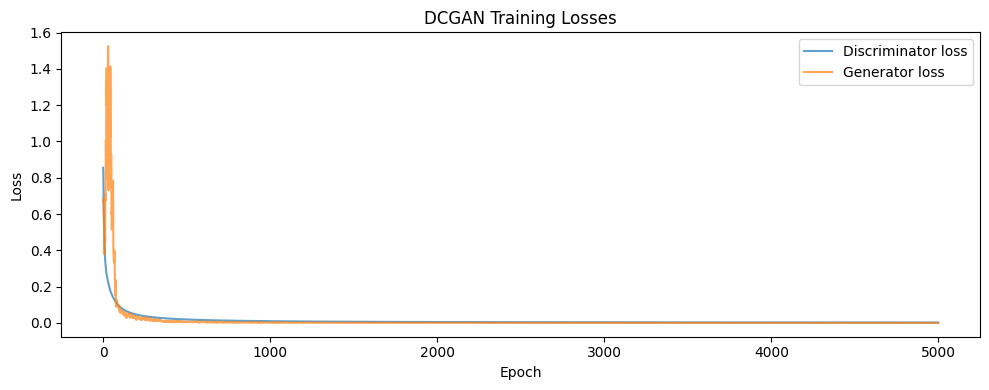

In [41]:
plt.figure(figsize=(10, 4))
plt.plot(d_losses, label='Discriminator loss', alpha=0.7)
plt.plot(g_losses, label='Generator loss',     alpha=0.7)
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('DCGAN Training Losses')
plt.legend(); plt.tight_layout()
plt.savefig("images/training_losses.png", dpi=100)
plt.show()

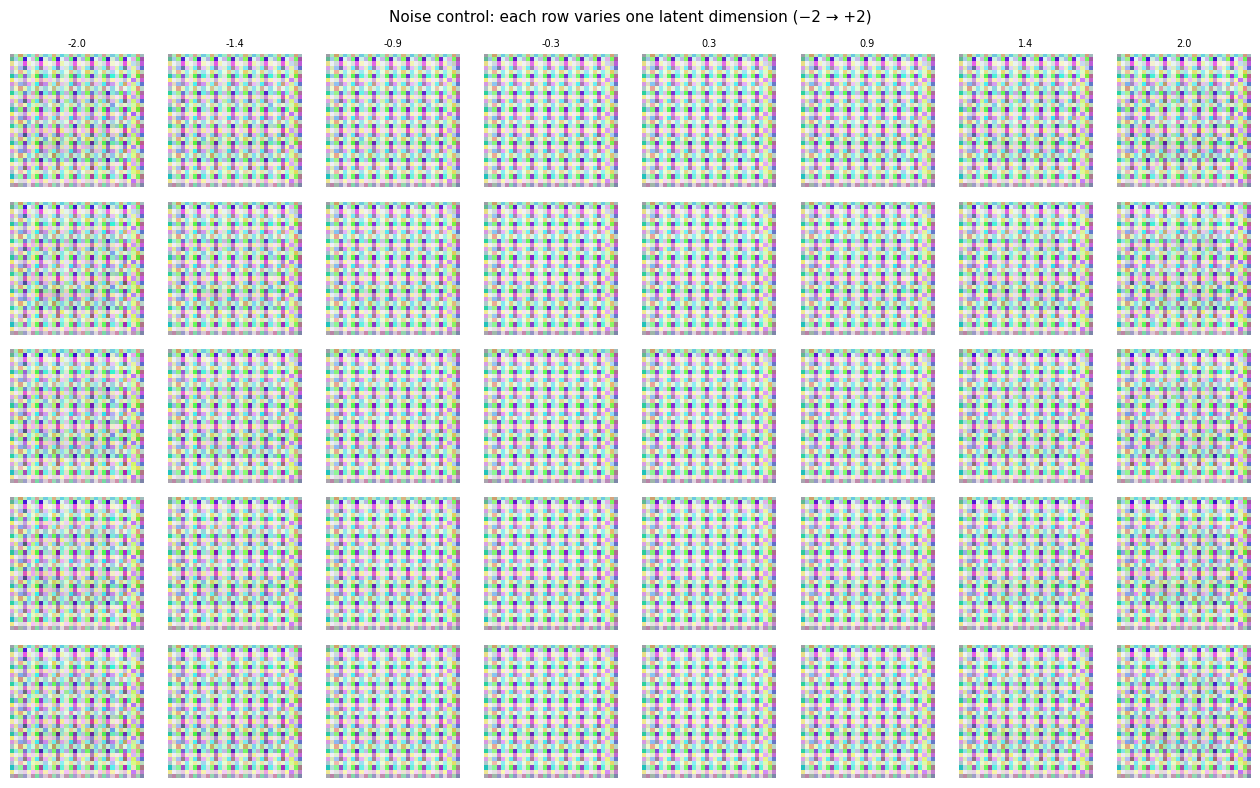

In [42]:
def show_noise_variation(generator, latent_dim=LATENT_DIM,
                         n_dims=5, n_steps=8):
    """Fix all dims to 0; sweep selected dims from -2 to +2."""
    fixed = np.zeros((1, latent_dim))

    fig, axs = plt.subplots(n_dims, n_steps,
                            figsize=(n_steps * 1.6, n_dims * 1.6))
    fig.suptitle("Noise control: each row varies one latent dimension "
                 "(−2 → +2)", fontsize=11)

    for row, dim in enumerate(range(n_dims)):
        for col, val in enumerate(np.linspace(-2, 2, n_steps)):
            z         = fixed.copy()
            z[0, dim] = val
            img = generator.predict(z, verbose=0)[0]
            img = np.clip(0.5 * img + 0.5, 0, 1)
            axs[row, col].imshow(img)
            axs[row, col].axis('off')
            if col == 0:
                axs[row, col].set_ylabel(f"dim {dim}", fontsize=8)
            if row == 0:
                axs[row, col].set_title(f"{val:.1f}", fontsize=7)

    plt.tight_layout()
    plt.savefig("images/noise_variation.png", dpi=120)
    plt.show()
    plt.close()

show_noise_variation(generator)

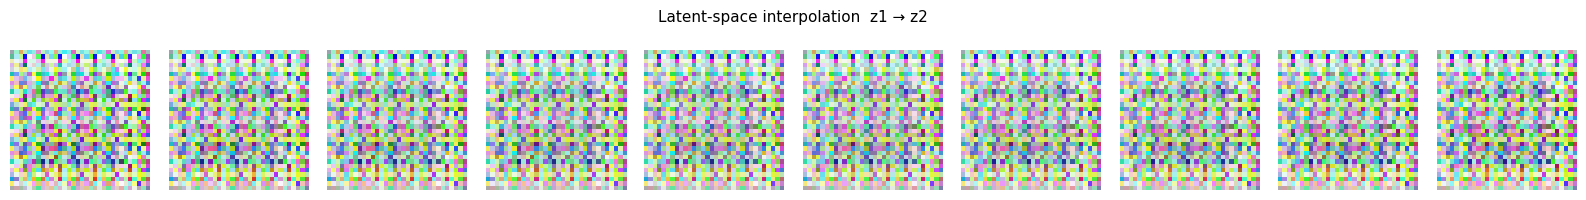

In [43]:
def show_noise_interpolation(generator, latent_dim=LATENT_DIM, n_steps=10):
    """Linear walk from one random noise vector to another."""
    z1 = np.random.normal(0, 1, (1, latent_dim))
    z2 = np.random.normal(0, 1, (1, latent_dim))
    zs = np.vstack([(1 - t) * z1 + t * z2
                    for t in np.linspace(0, 1, n_steps)])

    imgs = np.clip(0.5 * generator.predict(zs, verbose=0) + 0.5, 0, 1)

    fig, axs = plt.subplots(1, n_steps, figsize=(n_steps * 1.6, 2))
    fig.suptitle("Latent-space interpolation  z1 → z2", fontsize=11)
    for ax, img in zip(axs, imgs):
        ax.imshow(img)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig("images/noise_interpolation.png", dpi=120)
    plt.show()
    plt.close()

show_noise_interpolation(generator)

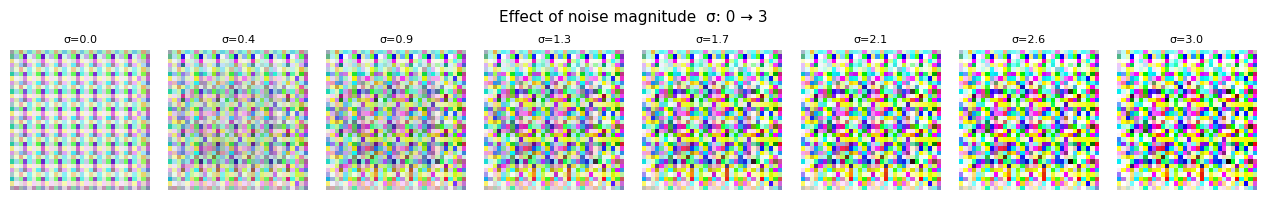

In [44]:
def show_noise_magnitude(generator, latent_dim=LATENT_DIM, n_steps=8):
    """Scale the same vector by σ = 0 → 3 to show amplitude effect."""
    base   = np.random.normal(0, 1, (1, latent_dim))
    scales = np.linspace(0, 3, n_steps)
    zs     = np.vstack([base * s for s in scales])

    imgs = np.clip(0.5 * generator.predict(zs, verbose=0) + 0.5, 0, 1)

    fig, axs = plt.subplots(1, n_steps, figsize=(n_steps * 1.6, 2))
    fig.suptitle("Effect of noise magnitude  σ: 0 → 3", fontsize=11)
    for ax, img, s in zip(axs, imgs, scales):
        ax.imshow(img)
        ax.set_title(f"σ={s:.1f}", fontsize=8)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig("images/noise_magnitude.png", dpi=120)
    plt.show()
    plt.close()

show_noise_magnitude(generator)